In [1]:
pip install seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Alishba University\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [3]:
movies = pd.read_csv("../data/tmdb_5000_movies.csv")

In [4]:
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [5]:
credits = pd.read_csv("../data/tmdb_5000_credits.csv")

In [6]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [7]:
print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)

Movies shape: (4803, 20)
Credits shape: (4803, 4)


In [8]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [9]:
credits.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  4803 non-null   int64
 1   title     4803 non-null   str  
 2   cast      4803 non-null   str  
 3   crew      4803 non-null   str  
dtypes: int64(1), str(3)
memory usage: 150.2 KB


In [10]:
print(movies.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='str')


In [11]:
print(credits.columns)

Index(['movie_id', 'title', 'cast', 'crew'], dtype='str')


In [12]:
print(movies["id"].head())
print(credits["movie_id"].head())

0     19995
1       285
2    206647
3     49026
4     49529
Name: id, dtype: int64
0     19995
1       285
2    206647
3     49026
4     49529
Name: movie_id, dtype: int64


In [13]:
df = movies.merge(
    credits,
    left_on="id",
    right_on="movie_id",
    how="inner"
)

In [14]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [15]:
df = df[
    (df["budget"] > 0) &
    (df["revenue"] > 0)
]

In [16]:
print(df.shape)

(3229, 24)


In [17]:
df["roi"] = (df["revenue"] - df["budget"]) / df["budget"]

In [18]:
df[["title_x", "budget", "revenue", "roi"]].head()

,title_x,budget,revenue,roi
0,Avatar,237000000,2787965087,10.763566
1,Pirates of the Caribbean: At World's End,300000000,961000000,2.203333
2,Spectre,245000000,880674609,2.594590
3,The Dark Knight Rises,250000000,1084939099,3.339756
4,John Carter,260000000,284139100,0.092843


In [19]:
roi_median = df["roi"].median()

print("Median ROI:", roi_median)

Median ROI: 1.3003662857142857


In [20]:
df["success"] = np.where(
    df["roi"] >= roi_median,
    1,
    0
)

In [21]:
print(df["success"].value_counts())

success
1    1615
0    1614
Name: count, dtype: int64


In [22]:
print(df["success"].value_counts(normalize=True))

success
1    0.500155
0    0.499845
Name: proportion, dtype: float64


In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 3229 entries, 0 to 4798
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                3229 non-null   int64  
 1   genres                3229 non-null   str    
 2   homepage              1347 non-null   str    
 3   id                    3229 non-null   int64  
 4   keywords              3229 non-null   str    
 5   original_language     3229 non-null   str    
 6   original_title        3229 non-null   str    
 7   overview              3229 non-null   str    
 8   popularity            3229 non-null   float64
 9   production_companies  3229 non-null   str    
 10  production_countries  3229 non-null   str    
 11  release_date          3229 non-null   str    
 12  revenue               3229 non-null   int64  
 13  runtime               3229 non-null   float64
 14  spoken_languages      3229 non-null   str    
 15  status                3229 non-null  

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.isnull().sum().sort_values(ascending=False)

homepage                1882
tagline                  245
genres                     0
id                         0
keywords                   0
original_language          0
original_title             0
overview                   0
popularity                 0
budget                     0
production_companies       0
production_countries       0
revenue                    0
release_date               0
runtime                    0
spoken_languages           0
status                     0
title_x                    0
vote_average               0
vote_count                 0
movie_id                   0
title_y                    0
cast                       0
crew                       0
roi                        0
success                    0
dtype: int64

In [26]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,movie_id,roi,success
count,3.229000e+03,3229.000000,3229.000000,3.229000e+03,3229.000000,3229.000000,3229.000000,3229.000000,3.229000e+03,3229.000000
mean,4.065444e+07,44780.705791,29.033689,1.212430e+08,110.724373,6.309353,977.287395,44780.705791,2.953822e+03,0.500155
std,4.439674e+07,74609.434723,36.165730,1.863029e+08,20.965694,0.873891,1414.309577,74609.434723,1.506101e+05,0.500077
min,1.000000e+00,5.000000,0.019984,5.000000e+00,41.000000,0.000000,0.000000,5.000000,-9.999995e-01,0.000000
25%,1.050000e+07,4958.000000,10.446722,1.700000e+07,96.000000,5.800000,178.000000,4958.000000,2.246328e-02,0.000000
50%,2.500000e+07,11451.000000,20.410354,5.518472e+07,107.000000,6.300000,471.000000,11451.000000,1.300366e+00,1.000000
75%,5.500000e+07,45272.000000,37.335721,1.462920e+08,121.000000,6.900000,1148.000000,45272.000000,3.420822e+00,1.000000
max,3.800000e+08,417859.000000,875.581305,2.787965e+09,338.000000,8.500000,13752.000000,417859.000000,8.499999e+06,1.000000


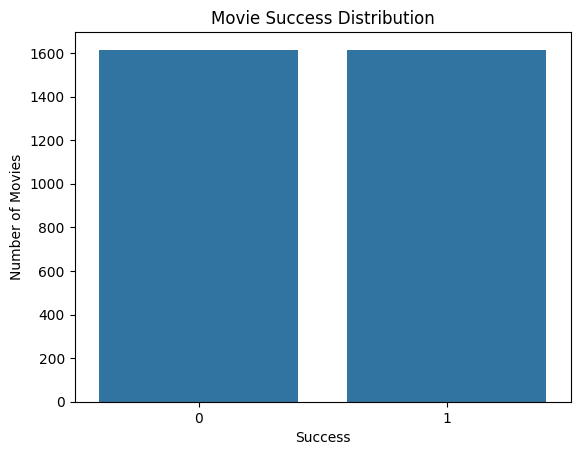

In [27]:
sns.countplot(data=df, x="success")

plt.title("Movie Success Distribution")
plt.xlabel("Success")
plt.ylabel("Number of Movies")

plt.show()

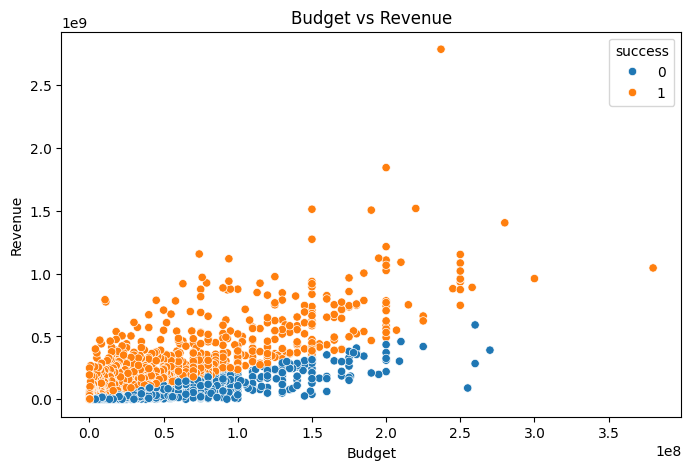

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="budget",
    y="revenue",
    hue="success"
)

plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.show()

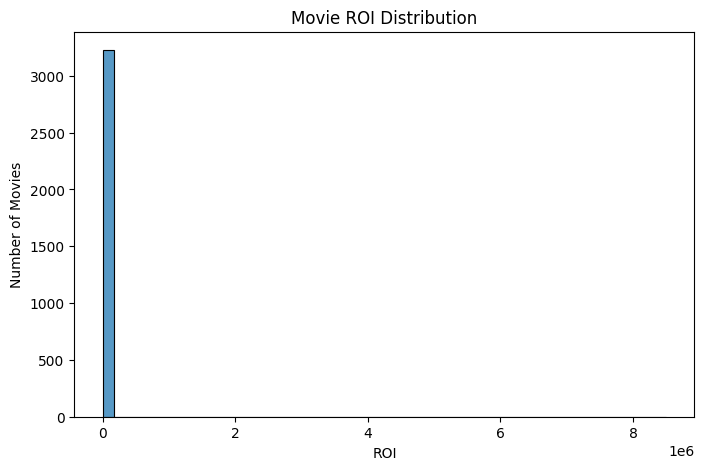

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="roi",
    bins=50
)

plt.title("Movie ROI Distribution")
plt.xlabel("ROI")
plt.ylabel("Number of Movies")

plt.show()

In [30]:
print(df.columns.tolist())

['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average', 'vote_count', 'movie_id', 'title_y', 'cast', 'crew', 'roi', 'success']


In [31]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing[missing > 0])

homepage    1882
tagline      245
dtype: int64


In [32]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [33]:
print("Budget <= 0:", (df["budget"] <= 0).sum())
print("Revenue <= 0:", (df["revenue"] <= 0).sum())

Budget <= 0: 0
Revenue <= 0: 0


In [34]:
df["roi_capped"] = df["roi"].clip(
    lower=df["roi"].quantile(0.01),
    upper=df["roi"].quantile(0.99)
)

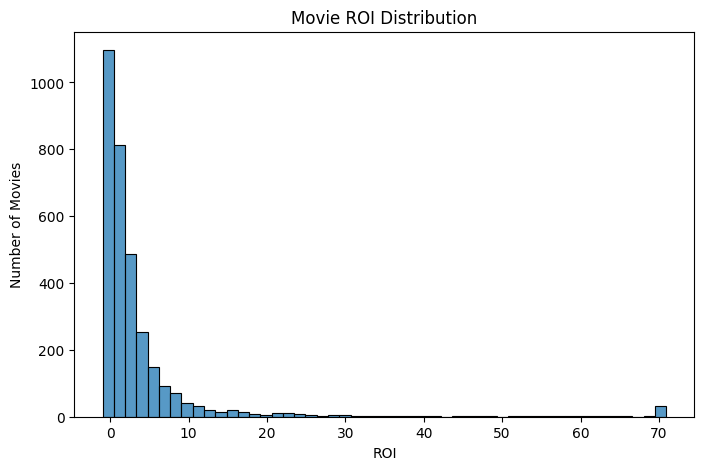

In [35]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="roi_capped",
    bins=50
)

plt.title("Movie ROI Distribution")
plt.xlabel("ROI")
plt.ylabel("Number of Movies")

plt.show()

In [36]:
roi_median = df["roi"].median()

print("Median ROI:", roi_median)

Median ROI: 1.3003662857142857


In [37]:
df["success"] = np.where(
    df["roi"] >= roi_median,
    1,
    0
)
print(df["success"].value_counts())
print(df["success"].value_counts(normalize=True))

success
1    1615
0    1614
Name: count, dtype: int64
success
1    0.500155
0    0.499845
Name: proportion, dtype: float64


In [38]:
df["success_label"] = df["success"].map({
    0: "Not Hit",
    1: "Hit"
})

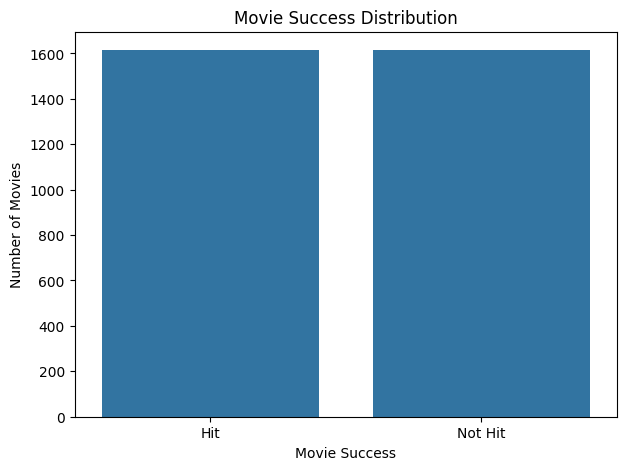

In [39]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="success_label"
)

plt.title("Movie Success Distribution")
plt.xlabel("Movie Success")
plt.ylabel("Number of Movies")

plt.show()

In [40]:
import ast
def get_first_genre(text):

    try:
        genres = ast.literal_eval(text)

        if len(genres) > 0:
            return genres[0]["name"]

        return "Unknown"

    except:
        return "Unknown"

df["main_genre"] = df["genres"].apply(get_first_genre)
print(df["main_genre"].value_counts())

main_genre
Drama              747
Comedy             634
Action             588
Adventure          288
Horror             197
Crime              141
Thriller           118
Animation           99
Fantasy             93
Science Fiction     79
Romance             70
Family              38
Documentary         30
Mystery             27
Western             22
Music               20
History             18
War                 18
Unknown              1
Foreign              1
Name: count, dtype: int64


In [41]:
print(df[["genres", "main_genre"]].head())

                                              genres main_genre
0  [{"id": 28, "name": "Action"}, {"id": 12, "nam...     Action
1  [{"id": 12, "name": "Adventure"}, {"id": 14, "...  Adventure
2  [{"id": 28, "name": "Action"}, {"id": 12, "nam...     Action
3  [{"id": 28, "name": "Action"}, {"id": 80, "nam...     Action
4  [{"id": 28, "name": "Action"}, {"id": 12, "nam...     Action


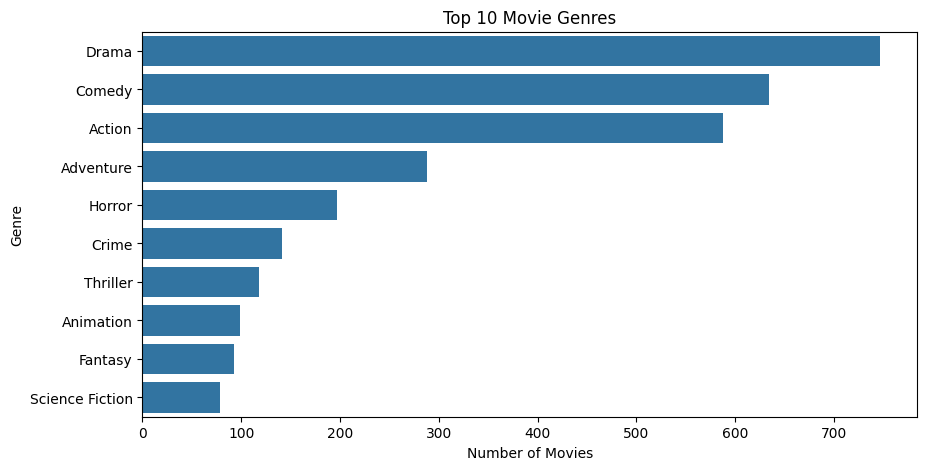

In [42]:
genre_counts = df["main_genre"].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

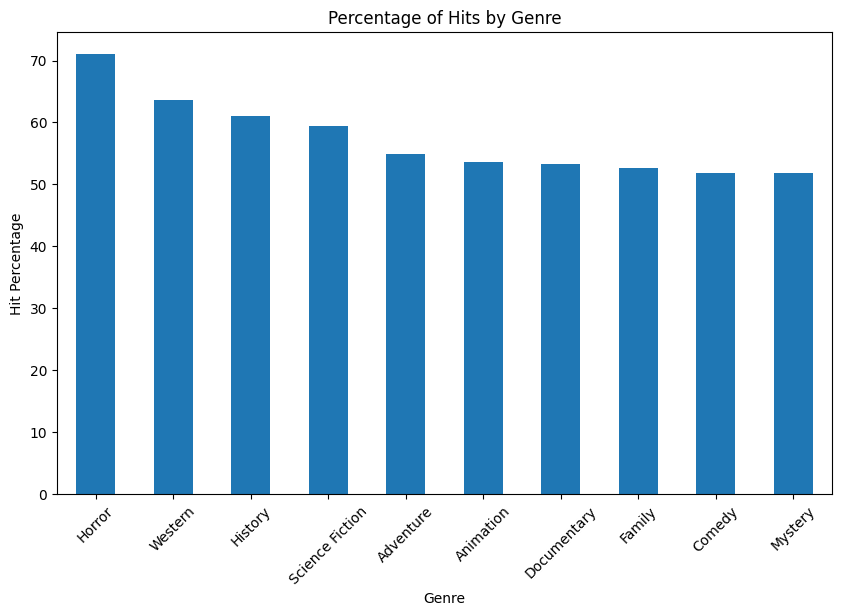

In [43]:
genre_success = pd.crosstab(
    df["main_genre"],
    df["success_label"],
    normalize="index"
) * 100
genre_success = genre_success.sort_values(
    "Hit",
    ascending=False
)
plt.figure(figsize=(10, 6))

genre_success["Hit"].head(10).plot(
    kind="bar"
)

plt.title("Percentage of Hits by Genre")
plt.xlabel("Genre")
plt.ylabel("Hit Percentage")

plt.xticks(rotation=45)

plt.show()

In [44]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)
df["release_year"] = df["release_date"].dt.year
print(df[["release_date", "release_year"]].head())

  release_date  release_year
0   2009-12-10          2009
1   2007-05-19          2007
2   2015-10-26          2015
3   2012-07-16          2012
4   2012-03-07          2012


In [45]:
df["release_month"] = df["release_date"].dt.month
print(df[["release_date", "release_month"]].head())

  release_date  release_month
0   2009-12-10             12
1   2007-05-19              5
2   2015-10-26             10
3   2012-07-16              7
4   2012-03-07              3


In [46]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Fall"
df["release_season"] = df["release_month"].apply(get_season)
print(df["release_season"].value_counts())

release_season
Fall      934
Summer    837
Winter    754
Spring    704
Name: count, dtype: int64


In [47]:
def count_items(text):

    try:
        items = ast.literal_eval(text)
        return len(items)

    except:
        return 0
df["num_production_companies"] = (
    df["production_companies"].apply(count_items)
)
print(
    df["num_production_companies"].describe()
)

count    3229.000000
mean        3.199752
std         2.169417
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        26.000000
Name: num_production_companies, dtype: float64


In [48]:
df["num_production_countries"] = (
    df["production_countries"].apply(count_items)
)
print(
    df["num_production_countries"].describe()
)

count    3229.000000
mean        1.396717
std         0.797457
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        12.000000
Name: num_production_countries, dtype: float64


In [49]:
print(df[["cast", "crew"]].head())

                                                cast  \
0  [{"cast_id": 242, "character": "Jake Sully", "...   
1  [{"cast_id": 4, "character": "Captain Jack Spa...   
2  [{"cast_id": 1, "character": "James Bond", "cr...   
3  [{"cast_id": 2, "character": "Bruce Wayne / Ba...   
4  [{"cast_id": 5, "character": "John Carter", "c...   

                                                crew  
0  [{"credit_id": "52fe48009251416c750aca23", "de...  
1  [{"credit_id": "52fe4232c3a36847f800b579", "de...  
2  [{"credit_id": "54805967c3a36829b5002c41", "de...  
3  [{"credit_id": "52fe4781c3a36847f81398c3", "de...  
4  [{"credit_id": "52fe479ac3a36847f813eaa3", "de...  


In [50]:
df["num_cast"] = df["cast"].apply(count_items)
print(df["num_cast"].describe())

count    3229.000000
mean       26.029111
std        21.483108
min         0.000000
25%        14.000000
50%        19.000000
75%        30.000000
max       224.000000
Name: num_cast, dtype: float64


In [51]:
df["num_crew"] = df["crew"].apply(count_items)
print(df["num_crew"].describe())

count    3229.000000
mean       33.944565
std        35.102669
min         0.000000
25%        12.000000
50%        20.000000
75%        44.000000
max       435.000000
Name: num_crew, dtype: float64


In [52]:
df["log_budget"] = np.log1p(df["budget"])
print(df["log_budget"].describe())

count    3229.000000
mean       16.799904
std         1.661809
min         0.693147
25%        16.166886
50%        17.034386
75%        17.822844
max        19.755682
Name: log_budget, dtype: float64


In [53]:
df["budget_per_minute"] = (
    df["budget"] / df["runtime"]
)
print((df["runtime"] <= 0).sum())

0


In [54]:
features = [
    "budget",
    "runtime",
    "release_year",
    "release_month",
    "main_genre",
    "num_production_companies",
    "num_production_countries",
    "num_cast",
    "num_crew",
    "log_budget",
    "budget_per_minute"
]

print(df[features].head())

      budget  runtime  release_year  release_month main_genre  \
0  237000000    162.0          2009             12     Action   
1  300000000    169.0          2007              5  Adventure   
2  245000000    148.0          2015             10     Action   
3  250000000    165.0          2012              7     Action   
4  260000000    132.0          2012              3     Action   

   num_production_companies  num_production_countries  num_cast  num_crew  \
0                         4                         2        83       153   
1                         3                         1        34        32   
2                         3                         2        83       155   
3                         4                         1       158       217   
4                         1                         1        27       132   

   log_budget  budget_per_minute  
0   19.283571       1.462963e+06  
1   19.519293       1.775148e+06  
2   19.316769       1.655405e+06  
3   19

In [55]:
missing = df[features].isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [56]:
X = df[features]
y = df["success"]

In [57]:
print(X.info())
print(y.value_counts())
print(X.describe())

<class 'pandas.DataFrame'>
Index: 3229 entries, 0 to 4798
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   budget                    3229 non-null   int64  
 1   runtime                   3229 non-null   float64
 2   release_year              3229 non-null   int32  
 3   release_month             3229 non-null   int32  
 4   main_genre                3229 non-null   str    
 5   num_production_companies  3229 non-null   int64  
 6   num_production_countries  3229 non-null   int64  
 7   num_cast                  3229 non-null   int64  
 8   num_crew                  3229 non-null   int64  
 9   log_budget                3229 non-null   float64
 10  budget_per_minute         3229 non-null   float64
dtypes: float64(3), int32(2), int64(5), str(1)
memory usage: 277.5 KB
None
success
1    1615
0    1614
Name: count, dtype: int64
             budget      runtime  release_year  release_month  \


In [58]:
print(df[["budget", "revenue", "roi", "success"]].head())
print(df["success"].value_counts())
print(df["main_genre"].value_counts().head(10))
print(X.describe())

      budget     revenue        roi  success
0  237000000  2787965087  10.763566        1
1  300000000   961000000   2.203333        1
2  245000000   880674609   2.594590        1
3  250000000  1084939099   3.339756        1
4  260000000   284139100   0.092843        0
success
1    1615
0    1614
Name: count, dtype: int64
main_genre
Drama              747
Comedy             634
Action             588
Adventure          288
Horror             197
Crime              141
Thriller           118
Animation           99
Fantasy             93
Science Fiction     79
Name: count, dtype: int64
             budget      runtime  release_year  release_month  \
count  3.229000e+03  3229.000000   3229.000000    3229.000000   
mean   4.065444e+07   110.724373   2001.680396       6.986373   
std    4.439674e+07    20.965694     13.279525       3.366014   
min    1.000000e+00    41.000000   1916.000000       1.000000   
25%    1.050000e+07    96.000000   1998.000000       4.000000   
50%    2.500000e+07

In [61]:
features = [
    "budget",
    "runtime",
    "release_year",
    "release_month",
    "main_genre",
    "num_production_companies",
    "num_production_countries",
    "num_cast",
    "num_crew",
    "log_budget",
    "budget_per_minute"
]

X = df[features]
y = df["success"]

numeric_features = [
    "budget",
    "runtime",
    "release_year",
    "release_month",
    "num_production_companies",
    "num_production_countries",
    "num_cast",
    "num_crew",
    "log_budget",
    "budget_per_minute"
]

categorical_features = [
    "main_genre"
]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2583, 11)
Testing data: (646, 11)


In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [64]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [65]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    )
}

In [66]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(name, "trained successfully!")

Logistic Regression trained successfully!
KNN trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


In [67]:
results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.667183,0.698529,0.588235,0.638655
0,Logistic Regression,0.633127,0.653571,0.566563,0.606965
1,KNN,0.592879,0.604167,0.538700,0.569558
2,Decision Tree,0.591331,0.607273,0.517028,0.558528


<Figure size 1000x600 with 0 Axes>

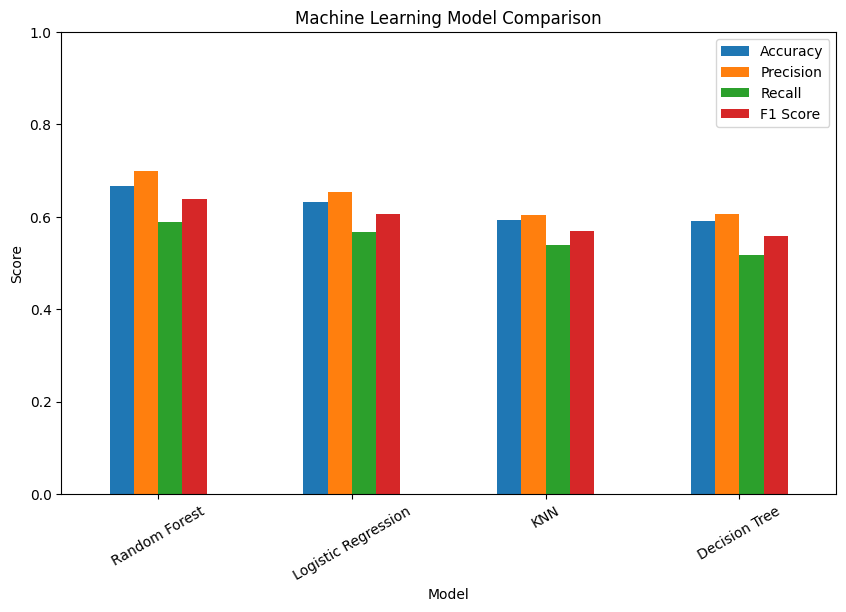

In [68]:
plt.figure(figsize=(10, 6))

results_plot = results_df.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

In [69]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [70]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

print(cm)

[[241  82]
 [133 190]]


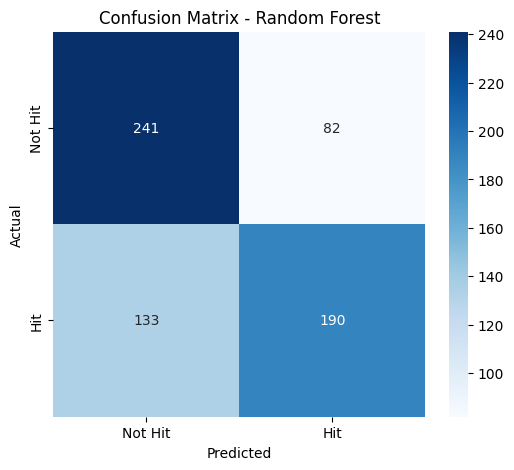

In [71]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Hit", "Hit"],
    yticklabels=["Not Hit", "Hit"]
)

plt.title("Confusion Matrix - " + best_model_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [72]:
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["Not Hit", "Hit"]
    )
)

              precision    recall  f1-score   support

     Not Hit       0.64      0.75      0.69       323
         Hit       0.70      0.59      0.64       323

    accuracy                           0.67       646
   macro avg       0.67      0.67      0.67       646
weighted avg       0.67      0.67      0.67       646



In [73]:
if best_model_name == "Random Forest":

    model = best_model.named_steps["model"]
    processor = best_model.named_steps["preprocessor"]

    feature_names = processor.get_feature_names_out()

    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    )

    print(importance_df.head(15))

                          Feature  Importance
6                   num__num_cast    0.144757
2               num__release_year    0.125637
7                   num__num_crew    0.117035
9          num__budget_per_minute    0.115554
8                 num__log_budget    0.093311
0                     num__budget    0.085923
1                    num__runtime    0.083070
3              num__release_month    0.059785
4   num__num_production_companies    0.051126
5   num__num_production_countries    0.027181
20         cat__main_genre_Horror    0.015922
10         cat__main_genre_Action    0.013484
16          cat__main_genre_Drama    0.009765
13         cat__main_genre_Comedy    0.008346
11      cat__main_genre_Adventure    0.006937


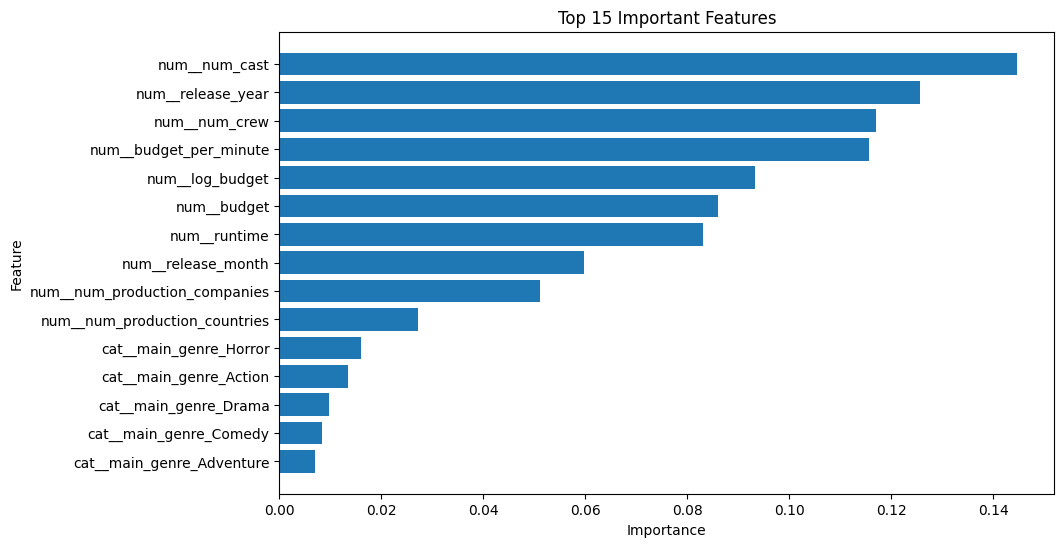

In [74]:
if best_model_name == "Random Forest":

    top_features = importance_df.head(15)

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_features["Feature"][::-1],
        top_features["Importance"][::-1]
    )

    plt.title("Top 15 Important Features")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.show()

In [76]:
import joblib
genre_list = sorted(
    df["main_genre"].dropna().unique().tolist()
)

model_package = {
    "model": best_model,
    "model_name": best_model_name,
    "features": features,
    "genres": genre_list
}

In [77]:
joblib.dump(
    model_package,
    "../models/movie_hit_model.pkl"
)

['../models/movie_hit_model.pkl']

In [78]:
loaded_package = joblib.load(
    "../models/movie_hit_model.pkl"
)

loaded_model = loaded_package["model"]

print("Loaded model:", loaded_package["model_name"])

Loaded model: Random Forest


In [79]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]

print("Prediction:", prediction)

Prediction: 1


In [80]:
probability = loaded_model.predict_proba(sample)[0]

print("Not Hit Probability:", probability[0])
print("Hit Probability:", probability[1])

Not Hit Probability: 0.25377192707602214
Hit Probability: 0.7462280729239776
